# scikit-FIBERS: Paper Figure Generation For Deeper Analysis
* For a given data/algorithm configuration (100 top bins) generate the following:
    * Bin custom heatmap (min of 1 filter)
    * Bin custom heatmap (min of 25 filter)
    * Bin custom heatmap (min of 50 filter)
    * Barplot of feature consistency (features appearing in any bin)
    * Boxplot of Adj HR's across imputation sets and random seed sets (two plots)
* Top bin closer examination:
    * Identify top performing bin out of 100 based on target metric (Adj. HR)
    * Print out top bin basic info (features and other bin characteristics)
    * Kaplan Mier Plot
    * Pre-fitness performance Tracking Plot
    * Pareto front plot
    * Feature importance estimate plot.

In [1]:
import os
import pickle
import pandas as pd
import collections
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
#from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
# Analysis Parameters
experiments = ['Fibers2.0_hla_7locus_product_DP3','Fibers2.0_hla_7locus_logrank_DP3_nofilter','Fibers2.0_hla_7locus_logrank_DP3_NoAg_nofilter']
experiment_name = 'Fibers2.0_hla_7locus_logrank_DP3_nofilter'
inputFolder = 'C:/Users/ryanu/Desktop/FIBERS_Deep/' + experiment_name
outputFolder = 'C:/Users/ryanu/Desktop/FIBERS_Output/'+ experiment_name

random_seeds = 10
replicates = 10
base_name = 'NewImp'
loci_list = ['A','B','C','DRB1','DQA1','DQB1','DRB345']

if not os.path.exists(outputFolder):
    os.mkdir(outputFolder)  

In [3]:
def match_prefix(feature, group_names):
    """
    :param feature: the feature
    :param group_names: the list of group names, must be exhaustive
    """
    for group_label in group_names:
        if feature.startswith(group_label):
            return group_label

    return "None"

def plot_custom_top_bin_population_heatmap(population,feature_names,group_names,legend_group_info,colors,max_bins,max_features,filtering=None,all_bin_labels=None,show=True,save=False,output_folder=None,data_name=None):
    """
    :param population: a list where each element is a list of specified features
    :param feature_list: an alphabetically sorted list containing each of the possible feature
    :param group_names: identifies unique text that identifies unique groups of features to group together in the heatmap separated by vertical lines
    :param legend_group_info: text for the different heatmap colors in the legend
    :param color_features: list of lists, where each sublists identifies all feature names in the data to be given a unique color in the heatmap other than default binary coloring
    :param colors: list of tuple objects identifying additional colors to use in the heatmap beyond the two default colors e.g. (0,0,1) for blue
    :param default_colors: list of tuple objects identifying the two default colors used in the heatmap for features unspecified and specified in bins e.g. (0,0,1) for blue
    :param max_bins: maximum number of bins in a population before the heatmap no longer prints these bin name lables on the y-axis
    :param max_features: maximum number of features in the dataset befor the heatmap no longer prints these feature name lables on the x-axis
    """
    fontsize = 20
    #Prepare bin population dataset
    feature_index_map = {}
    for i in range(len(feature_names)):
        feature_index_map[feature_names[i]] = i #create feature to featuer position index mapping

    graph_df = [] #create dataset of bin values
    for bin in population:
        temp_arr = [0] * len(feature_names)
        for feature in bin:
            temp_arr[feature_index_map[feature]] = 1
        graph_df.append(temp_arr)

    # Define bin names for plot
    if all_bin_labels == None:
        bin_names = []
        for i in range(len(population)):
            bin_names.append("Imp " + str(i + 1))
    else:
        bin_names = all_bin_labels

    graph_df = pd.DataFrame(graph_df, bin_names, feature_names) #data, index, columns

    if filtering != None:
        tdf = graph_df
        tdf = pd.DataFrame(tdf.sum(axis=0), columns=['Count']).sort_values('Count', ascending=False)
        tdf = tdf[tdf['Count'] >= filtering]
        graph_df = graph_df[list(tdf.index)]
        feature_names = graph_df.columns.tolist()

    #Re order dataframe based on specified group names
    prefix_columns = {prefix: [col for col in graph_df.columns if col.startswith(prefix)] for prefix in group_names} # Get the columns starting with each prefix
    ordered_columns = sum(prefix_columns.values(), []) # Concatenate the columns lists in the desired order
    graph_df = graph_df[ordered_columns] # Reorder the DataFrame columns

    #Prepare for group lines in the figure
    group_size_counter =  group_size_counter = collections.defaultdict(int)

    group_list = [[] for _ in range(len(group_names))] #list of feature lists by group
    for feature in feature_names:
        p = match_prefix(feature, group_names)
        group_size_counter[p] += 1
        index = group_names.index(p)
        group_list[index].append(feature) 

    group_counter_sorted = []
    for name in group_names:
        group_counter_sorted.append((name,group_size_counter[name]))

    #Define color lists
    index_dict = {}
    count = 1
    for group in group_list:
        for feature in group:
            index_dict[feature] = count
        count += 1

    for feature in graph_df.columns: #for each feature
        if feature in index_dict:
            for i in range(len(graph_df[feature])):
                if graph_df[feature][i] == 1:
                    graph_df[feature][i] = index_dict[feature]
    num_bins = len(population) #tmp

    #Identify if one group is not represented (to readjust colors used in colormap)
    code = 1 #starts with specified features
    remove_colors = []
    for group in group_names:
        count = (graph_df == code).sum().sum()
        if count == 0:
            remove_colors.append(colors[code])
        code += 1
    print(remove_colors)
    print(colors)
    applied_colors = [x for x in colors if x not in remove_colors]

    #Redo dataframe encoding
    code = 1
    if applied_colors != colors: #redo value encoding
        for i in range(0,len(group_names)):
            count = (graph_df == code).sum().sum()
            if count == 0:
                graph_df = graph_df.applymap(lambda x: x - 1 if x > code else x)
            else:
                code +=1
                
    #Prepare color mapping
    #custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=len(colors))
    custom_cmap = ListedColormap(applied_colors, 'custom_cmap', N=len(applied_colors))

    # iterate through df columns and adjust values as necessary
    if num_bins > max_bins:  #
        if len(feature_names) > max_features: #over max bins and max features - fixed plot with no labels
            fig_size = (max_features // 2, max_bins // 2)
            # Create a heatmap using Seaborn
            plt.subplots(figsize=fig_size)
            ax=sns.heatmap(graph_df, xticklabels=False, yticklabels=False,
                        square=True, cmap=custom_cmap, cbar_kws={"shrink": .75}, cbar=False)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
        else: #Over max bins, but under max features
            fig_size = (len(feature_names)// 2, max_bins  // 2)
            # Create a heatmap using Seaborn
            plt.subplots(figsize=fig_size)
            ax=sns.heatmap(graph_df, yticklabels=False,
                        square=True, cmap=custom_cmap, cbar_kws={"shrink": .75}, cbar=False)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    else:
        if len(feature_names) > max_features: #under max bins but over max features 
            fig_size = (max_features // 2, num_bins // 2)
            # Create a heatmap using Seaborn
            plt.subplots(figsize=fig_size)
            ax=sns.heatmap(graph_df, xticklabels=False, square=True, cmap=custom_cmap,
                        cbar_kws={"shrink": .75}, cbar=False)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
        else:
            fig_size = (len(feature_names)// 2, num_bins // 2)
            # Create a heatmap using Seaborn
            plt.subplots(figsize=fig_size)
            ax=sns.heatmap(graph_df, square=True, cmap=custom_cmap,
                        cbar_kws={"shrink": .75}, cbar=False)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    legend_elements = []
    index = 0
    for color in colors:
        legend_elements.append(mpatches.Patch(color=color,label=legend_group_info[index]))
        index += 1

    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=fontsize)

    running_count = 0
    for name, count in group_counter_sorted:
        running_count += count
        ax.vlines(running_count, colors="Black", *ax.get_ylim())

    plt.xlabel('Features',fontsize=fontsize)
    plt.ylabel('Top Bins',fontsize=fontsize)

    if save:
        plt.savefig(output_folder+'/'+data_name+'_top_bins_custom_pop_heatmap_filter_'+str(filtering)+'.png', bbox_inches="tight")
    if show:
        plt.show()


### Gather all Bin information

In [4]:
#Custom heatmaps that combines the top bins across data imputations for each random seed (10 figures)
all_top_bins = [] # list of all 100 bin objects 
all_bin_labels = []
all_feature_names = set()
for replicate in range(1,replicates+1): #one indexed datasets
    top_bin_pop = []
    replicate_feature_names = set()
    for random_seed in range(0, random_seeds):  #for each replicate
        data_name = base_name+'_'+str(replicate)

        #Unpickle FIBERS Object
        with open(inputFolder+'/'+data_name+'/'+data_name+'_'+str(random_seed)+'_fibers.pickle', 'rb') as f:
            fibers = pickle.load(f)

        #Get top bin object for current fibers population
        bin_index = 0 #top bin
        bin = fibers.set.bin_pop[bin_index]
        feature_names = fibers.feature_names
        all_feature_names.update(set(feature_names))
        replicate_feature_names.update(set(feature_names))
        top_bin_pop.append(bin)
        all_top_bins.append(bin)
        all_bin_labels.append("Seed_" + str(random_seed)+" Imp_"+str(replicate))

### Generate Custom Heatmaps

[]
[(0.95, 0.95, 1), (0, 0, 1), (1, 0, 0), (0, 1, 0), (0.5, 0, 1), (1, 0, 1), (1, 0.5, 0), (1, 1, 0)]
[]
[(0.95, 0.95, 1), (0, 0, 1), (1, 0, 0), (0, 1, 0), (0.5, 0, 1), (1, 0, 1), (1, 0.5, 0), (1, 1, 0)]
[(0, 1, 0), (1, 0, 1), (1, 0.5, 0), (1, 1, 0)]
[(0.95, 0.95, 1), (0, 0, 1), (1, 0, 0), (0, 1, 0), (0.5, 0, 1), (1, 0, 1), (1, 0.5, 0), (1, 1, 0)]


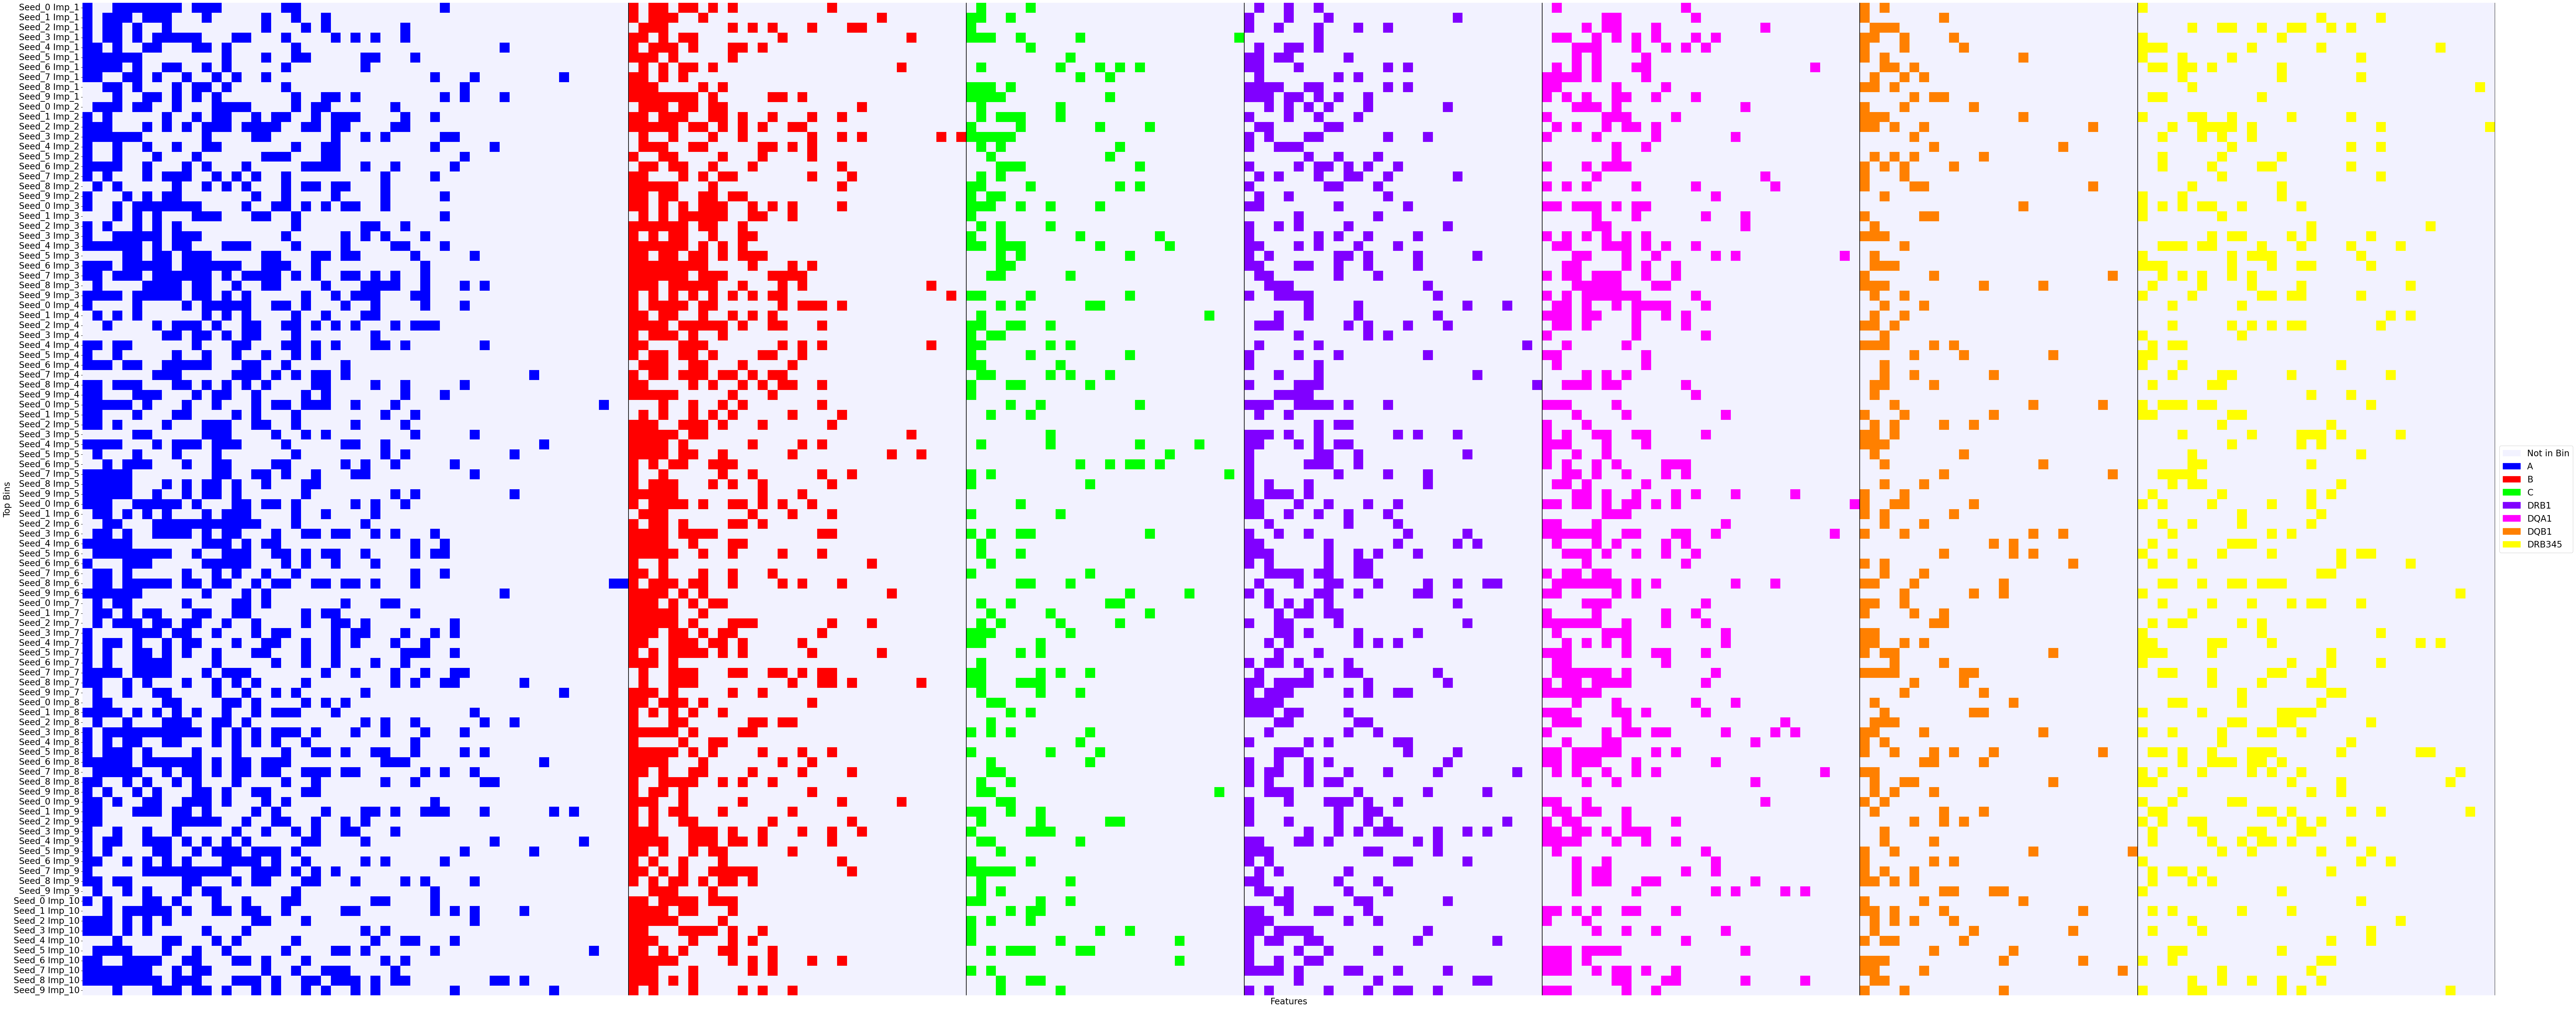

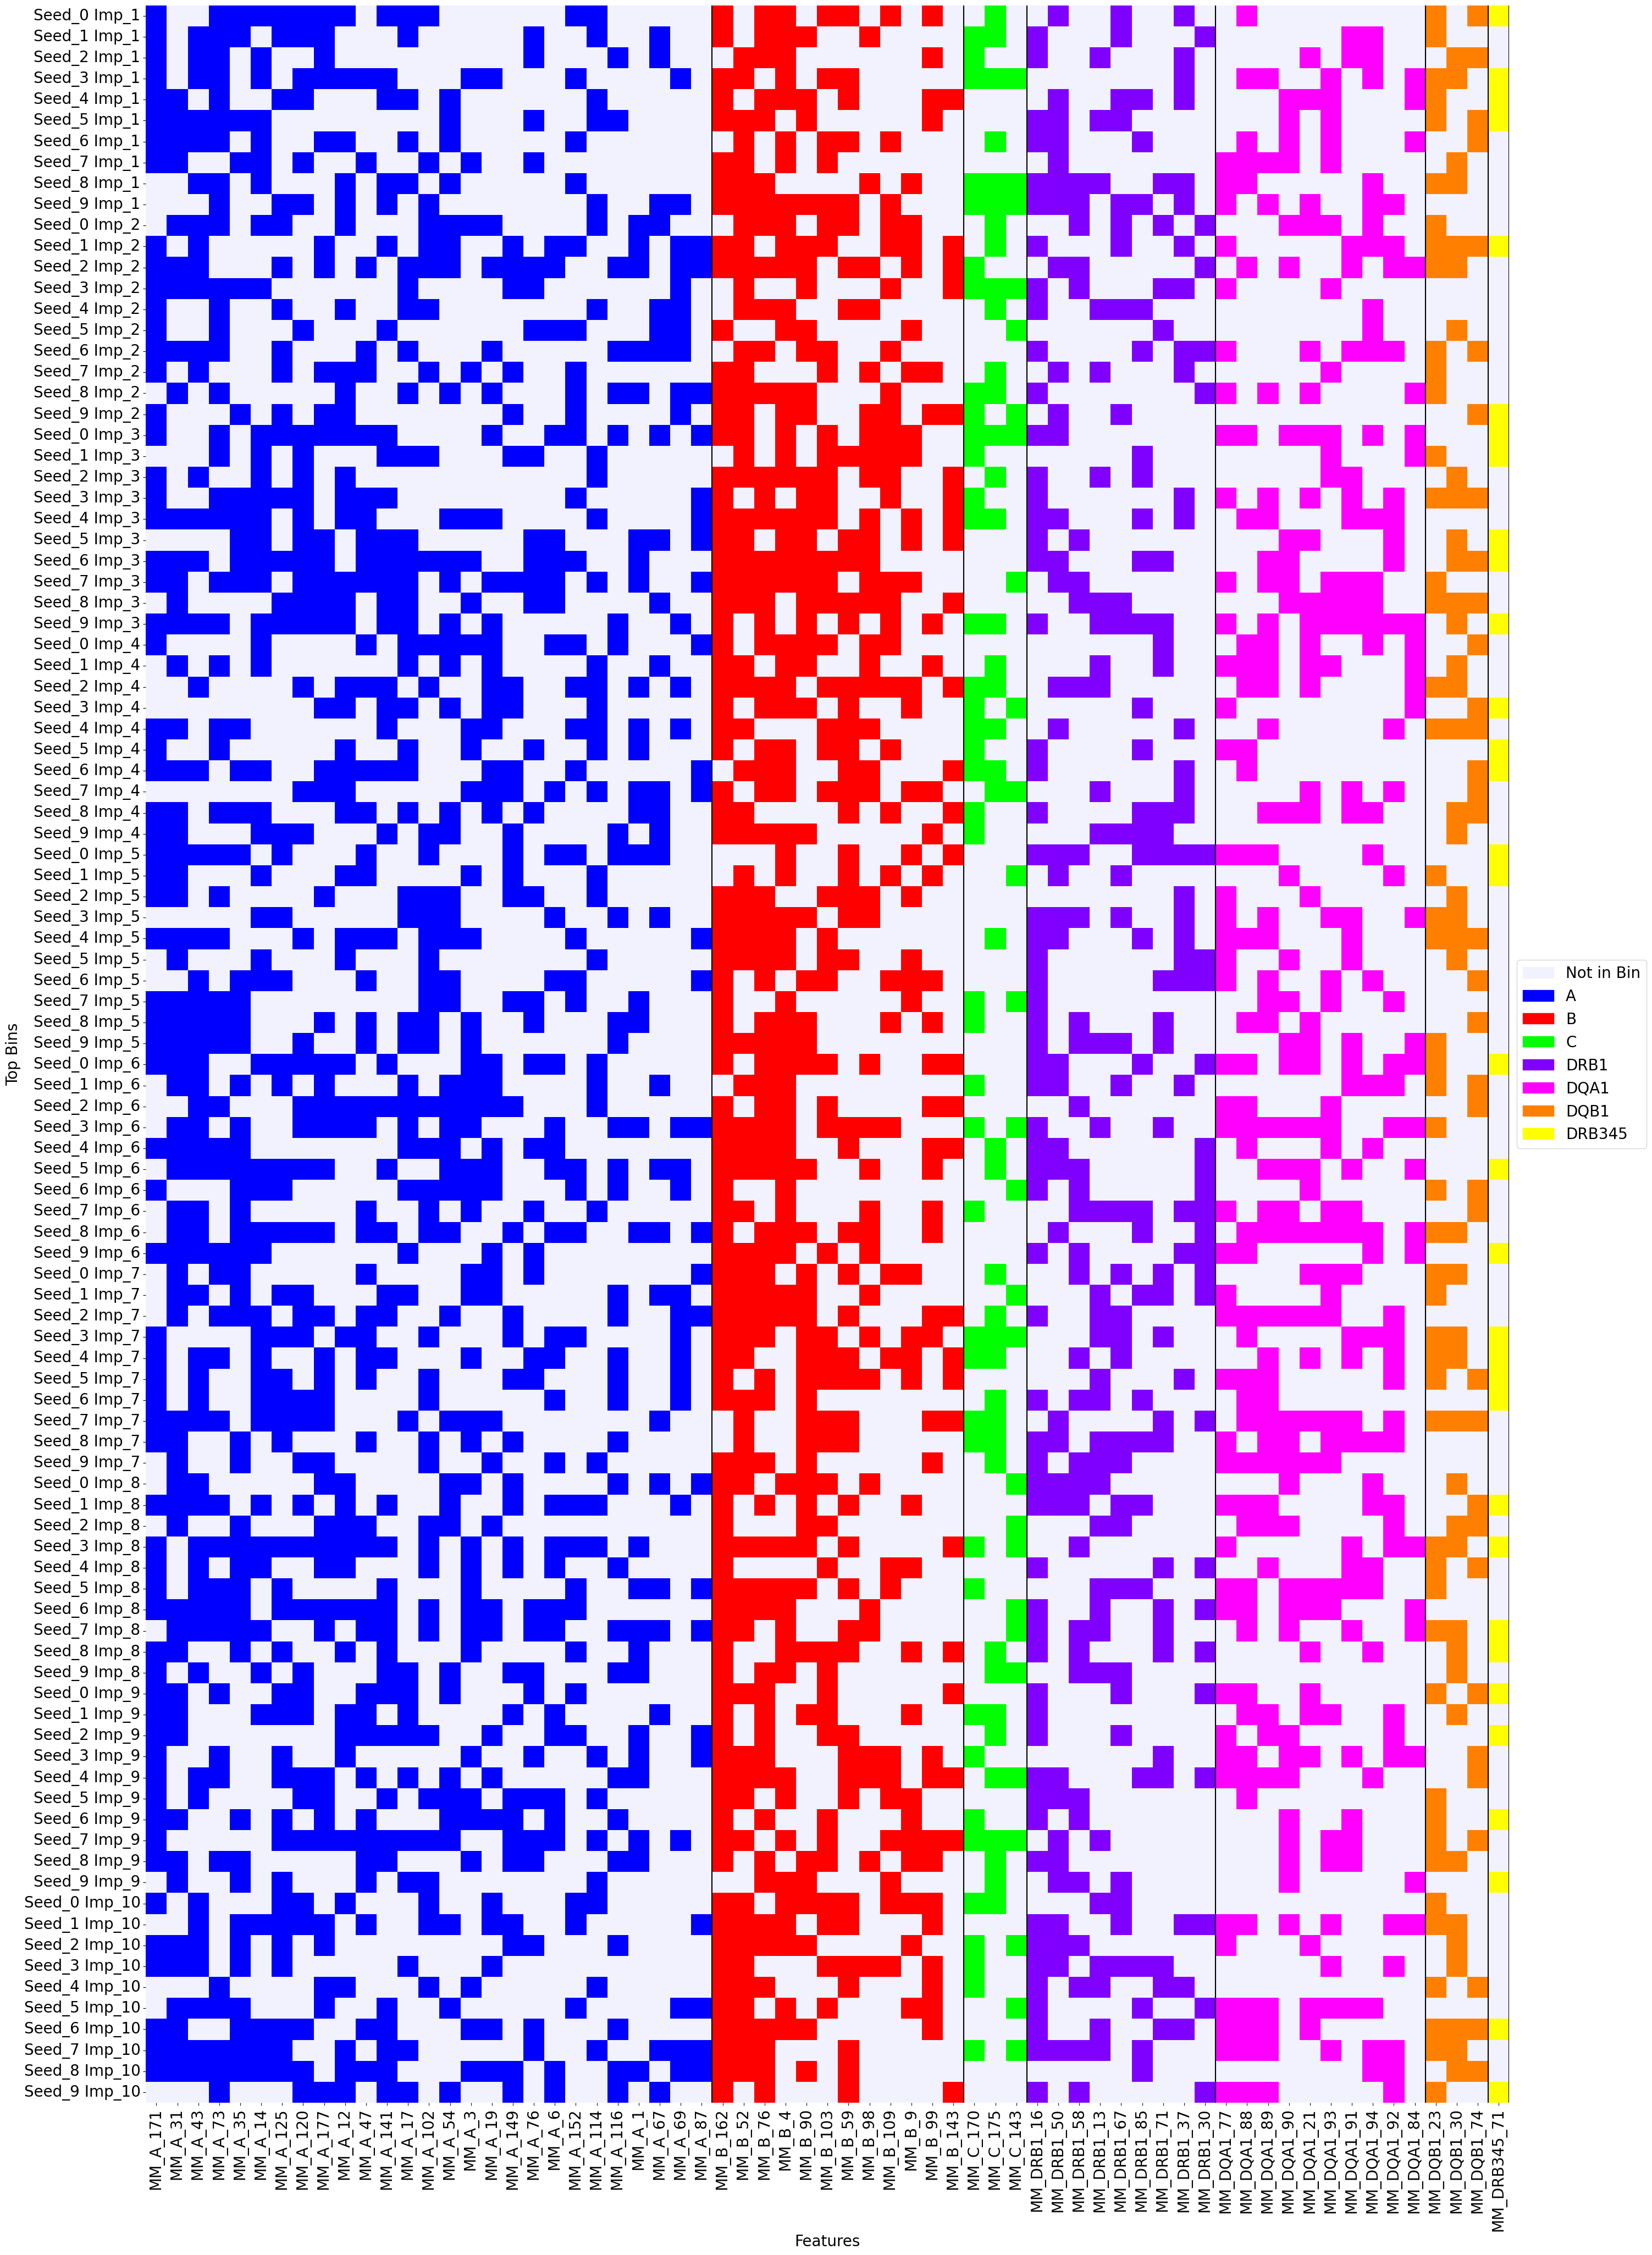

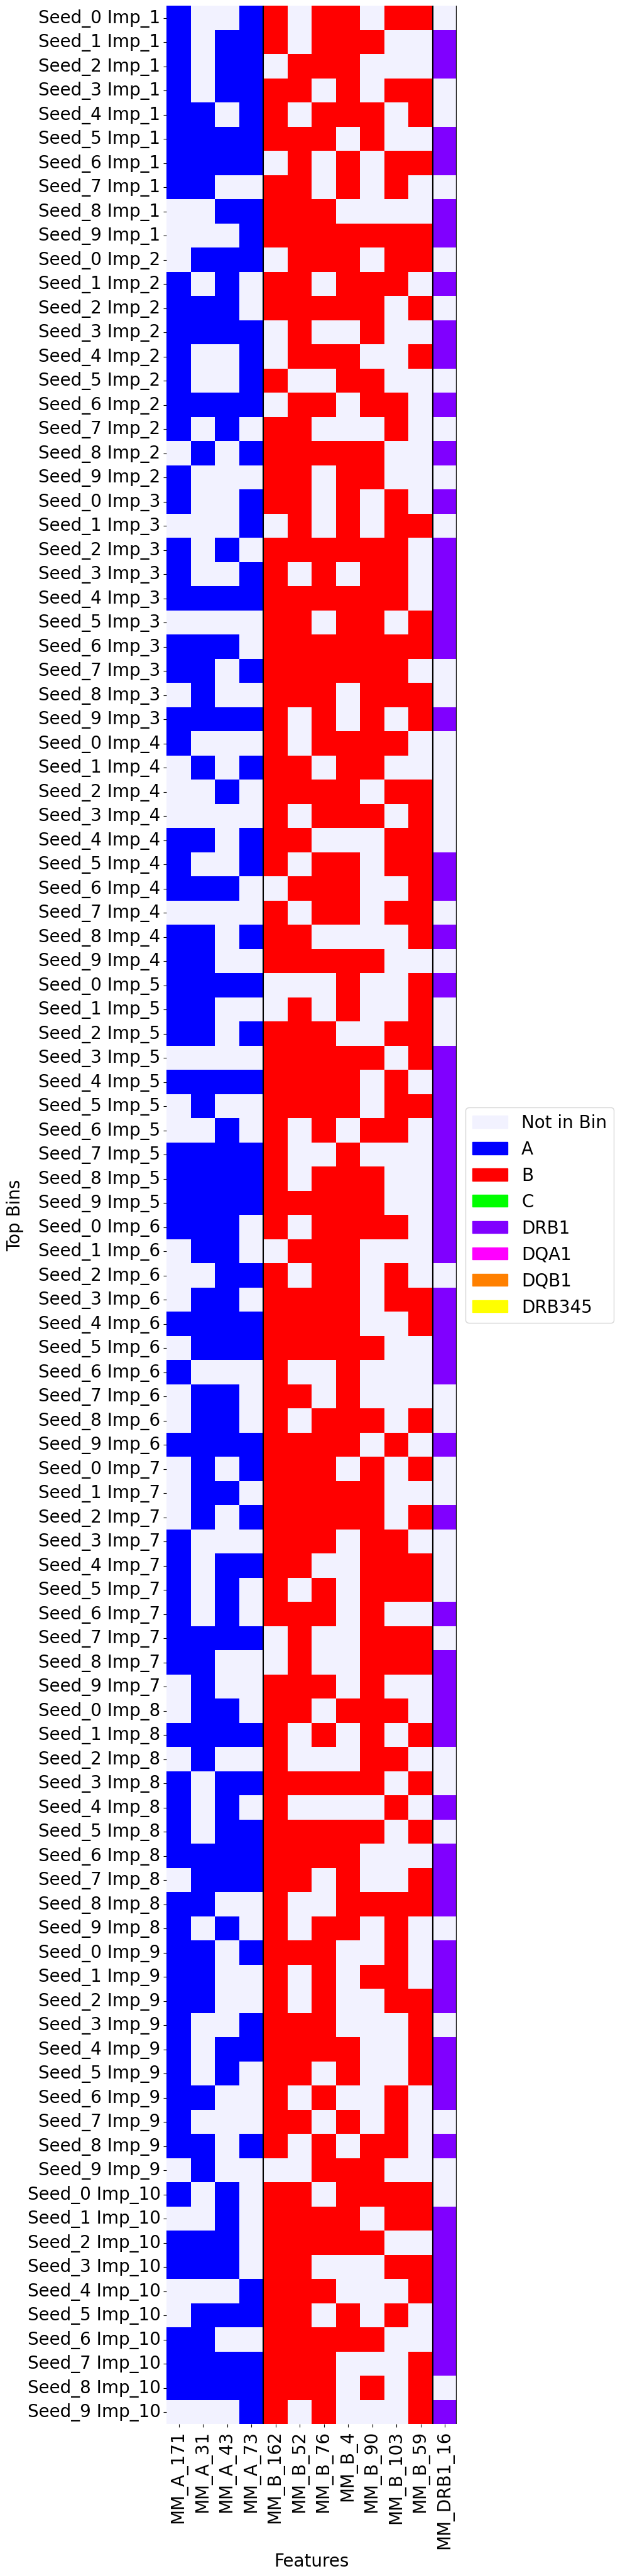

In [5]:
#Generate Top-bin Custom Heatmap across replicates and random seeds
# COLORS:    very light blue, blue, red, green, purple, pink, orange, yellow, light blue, grey
all_colors = [(0, 0, 1),(1, 0, 0),(0, 1, 0),(0.5, 0, 1),(1, 0, 1),(1, 0.5, 0),(1, 1, 0),(0, 1, 1),(0.5, 0.5, 0.5)] 
max_bins = 200
max_features = 200
group_names = []
legend_group_info = ['Not in Bin']
colors = [(.95, .95, 1)]
filtering = 1
i = 0
for locus in loci_list:
    group_names.append('MM_'+str(locus))
    legend_group_info.append(locus)
    colors.append(all_colors[i])
    i += 1

#Generate Top-bin Custom Heatmap (filtering out zeros) across replicates and random seeds
population = pd.DataFrame([vars(instance) for instance in all_top_bins])
population = population['feature_list']
plot_custom_top_bin_population_heatmap(population, list(all_feature_names), group_names,legend_group_info,colors,max_bins,max_features,filtering=filtering, all_bin_labels=all_bin_labels,save=True,show=False,output_folder=outputFolder,data_name=base_name)

#Generate Top-bin Custom Heatmap across replicates and random seeds
filtering = 25
plot_custom_top_bin_population_heatmap(population, list(all_feature_names), group_names,legend_group_info,colors,max_bins,max_features,filtering=filtering, all_bin_labels=all_bin_labels,save=True,show=False,output_folder=outputFolder,data_name=base_name)

#Generate Top-bin Custom Heatmap across replicates and random seeds
filtering = 50
plot_custom_top_bin_population_heatmap(population, list(all_feature_names), group_names,legend_group_info,colors,max_bins,max_features,filtering=filtering, all_bin_labels=all_bin_labels,save=True,show=False,output_folder=outputFolder,data_name=base_name)


### Generate AA-MM Frequency Plots

In [6]:
def feature_frequency_barplot(population,feature_names_local,filtering,save=True,show=False):
    #Prepare bin population dataset
    feature_index_map = {}
    for i in range(len(feature_names_local)):
        feature_index_map[feature_names_local[i]] = i #create feature to featuer position index mapping

    graph_df = [] #create dataset of bin values
    for bin in population:
        temp_arr = [0] * len(feature_names_local)
        for feature in bin:
            temp_arr[feature_index_map[feature]] = 1
        graph_df.append(temp_arr)

    # Define bin names for plot
    if all_bin_labels == None:
        bin_names = []
        for i in range(len(population)):
            bin_names.append("Imp " + str(i + 1))
    else:
        bin_names = all_bin_labels

    graph_df = pd.DataFrame(graph_df, bin_names, feature_names_local) #data, index, columns

    if filtering != None:
        tdf = graph_df
        tdf = pd.DataFrame(tdf.sum(axis=0), columns=['Count']).sort_values('Count', ascending=False)
        tdf = tdf[tdf['Count'] >= filtering]
        graph_df = graph_df[list(tdf.index)]
        feature_names_local = graph_df.columns.tolist()
    print(graph_df)

    # Calculate the frequency of 1's for each column
    frequency_of_ones = graph_df.sum()  # Sum of 1's per column

    # Create a barplot for the frequency of 1's
    plt.figure(figsize=(15, 5))
    sns.barplot(x=frequency_of_ones.index, y=frequency_of_ones.values)
    plt.xticks(rotation=90, fontsize=5)
    # Set plot labels and title
    plt.xlabel('AA-MM Positions')
    plt.ylabel('Top Bin Inclusion Count (100 Bins)')

    if save:
        plt.savefig(outputFolder+'/'+base_name+'_top_bins_frequency_barplot_filter_'+str(filtering)+'.png', bbox_inches="tight")
    if show:
        plt.show()

               MM_B_162  MM_B_52  MM_B_76  MM_A_171  MM_B_4  MM_DRB1_16  \
Seed_0 Imp_1          1        0        1         1       1           0   
Seed_1 Imp_1          1        0        1         1       1           1   
Seed_2 Imp_1          0        1        1         1       1           1   
Seed_3 Imp_1          1        1        0         1       1           0   
Seed_4 Imp_1          1        0        1         1       1           0   
...                 ...      ...      ...       ...     ...         ...   
Seed_5 Imp_10         1        1        0         0       1           1   
Seed_6 Imp_10         1        1        1         1       1           1   
Seed_7 Imp_10         1        1        1         1       0           1   
Seed_8 Imp_10         1        1        1         1       0           0   
Seed_9 Imp_10         1        0        1         0       0           1   

               MM_A_31  MM_A_43  MM_A_73  MM_B_90  ...  MM_DRB345_26  MM_C_21  \
Seed_0 Imp_1      

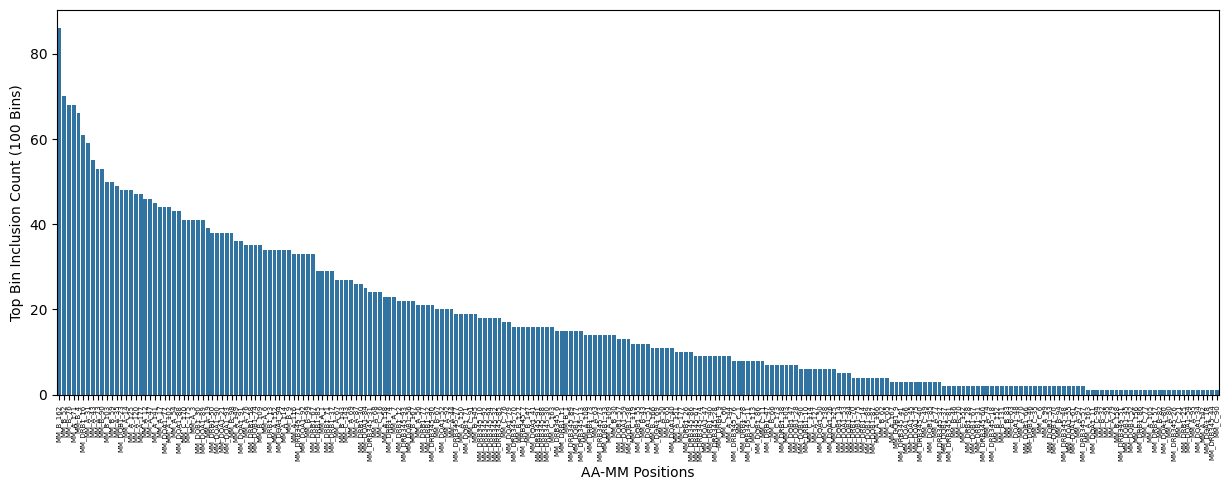

               MM_B_162  MM_B_52  MM_B_76  MM_A_171  MM_B_4  MM_DRB1_16  \
Seed_0 Imp_1          1        0        1         1       1           0   
Seed_1 Imp_1          1        0        1         1       1           1   
Seed_2 Imp_1          0        1        1         1       1           1   
Seed_3 Imp_1          1        1        0         1       1           0   
Seed_4 Imp_1          1        0        1         1       1           0   
...                 ...      ...      ...       ...     ...         ...   
Seed_5 Imp_10         1        1        0         0       1           1   
Seed_6 Imp_10         1        1        1         1       1           1   
Seed_7 Imp_10         1        1        1         1       0           1   
Seed_8 Imp_10         1        1        1         1       0           0   
Seed_9 Imp_10         1        0        1         0       0           1   

               MM_A_31  MM_A_43  MM_A_73  MM_B_90  ...  MM_C_6  MM_A_99  \
Seed_0 Imp_1         0  

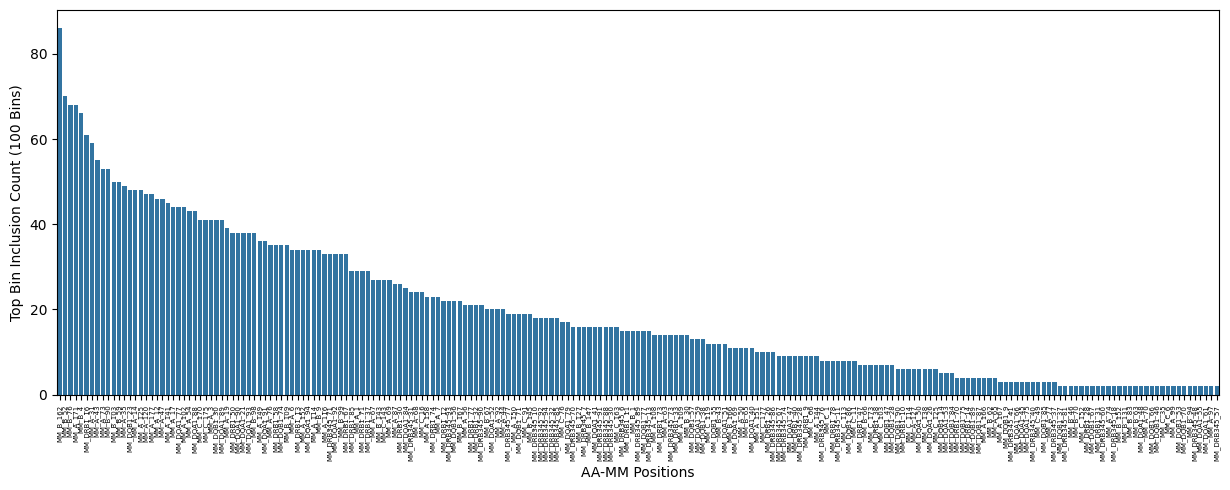

               MM_B_162  MM_B_52  MM_B_76  MM_A_171  MM_B_4  MM_DRB1_16  \
Seed_0 Imp_1          1        0        1         1       1           0   
Seed_1 Imp_1          1        0        1         1       1           1   
Seed_2 Imp_1          0        1        1         1       1           1   
Seed_3 Imp_1          1        1        0         1       1           0   
Seed_4 Imp_1          1        0        1         1       1           0   
...                 ...      ...      ...       ...     ...         ...   
Seed_5 Imp_10         1        1        0         0       1           1   
Seed_6 Imp_10         1        1        1         1       1           1   
Seed_7 Imp_10         1        1        1         1       0           1   
Seed_8 Imp_10         1        1        1         1       0           0   
Seed_9 Imp_10         1        0        1         0       0           1   

               MM_A_31  MM_A_43  MM_A_73  MM_B_90  ...  MM_DQA1_51  MM_B_166  \
Seed_0 Imp_1       

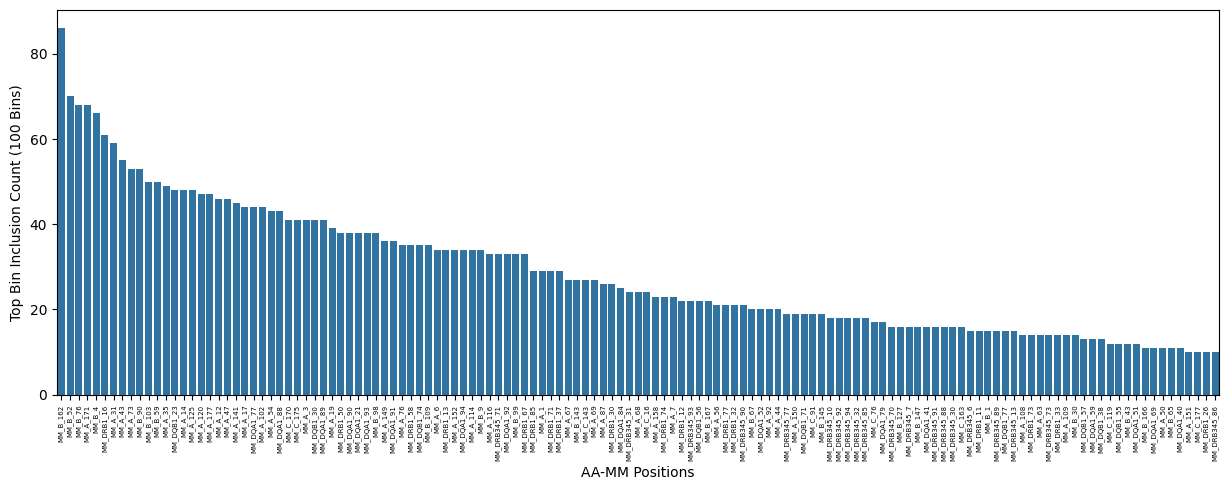

In [7]:
filtering = 1
feature_frequency_barplot(population,list(all_feature_names),filtering,save=True,show=True)

filtering = 2
feature_frequency_barplot(population,list(all_feature_names),filtering,save=True,show=True)

filtering = 10
feature_frequency_barplot(population,list(all_feature_names),filtering,save=True,show=True)

### Other Summary Plots (100 bins)

In [8]:
def hr_boxplot(df, x, y,save=True,show=True):
    plt.figure(figsize=(6, 6))
    sns.boxplot(x=x, y=y, data=df)
    plt.title('Boxplot of HR values by '+str(x))
    plt.xticks(rotation=90)
    if save:
        plt.savefig(outputFolder+'/'+base_name+'_HR_BoxPlot_'+str(x)+'.png', bbox_inches="tight")
    if show:
        plt.show()

C:/Users/ryanu/Desktop/FIBERS_Deep/Fibers2.0_hla_7locus_logrank_DP3_nofilter/Fibers2.0_hla_7locus_logrank_DP3_nofilter_summary.csv


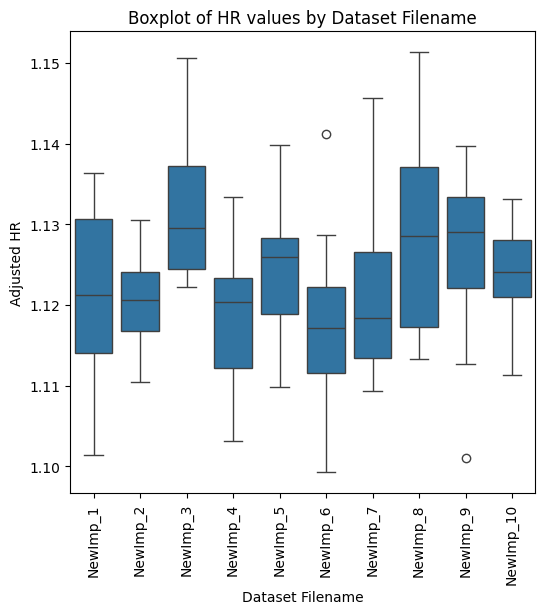

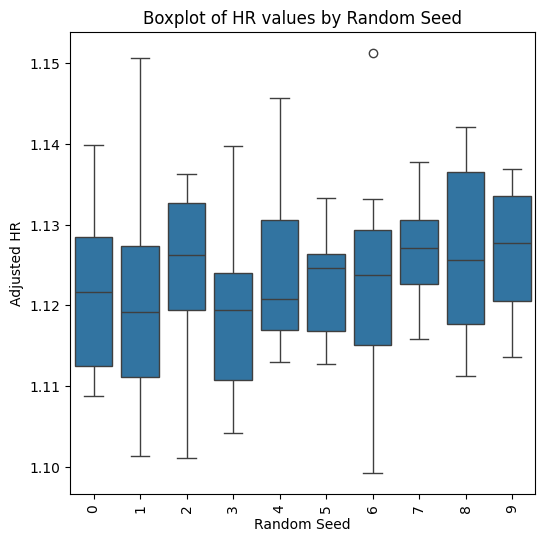

In [9]:
filename = inputFolder+'/'+experiment_name+'_summary.csv'
print(filename)
df_summary = pd.read_csv(filename)
data_name_col = 'Dataset Filename'
seed_name_col = 'Random Seed'
HR_col = 'Adjusted HR'
hr_boxplot(df_summary,data_name_col,HR_col,save=True,show=True)
hr_boxplot(df_summary,seed_name_col,HR_col,save=True,show=True)

### Scatterplot

In [10]:
def scatterplot_compare(df,x,y,image_name,x_pos,y_pos,save=True,show=True):

    # Fit a linear regression model
    X = df[[x]]  # Independent variable (needs to be 2D)
    Y = df[y]    # Dependent variable
    model = LinearRegression()
    model.fit(X, Y)

    # Predict values and calculate R^2
    y_pred = model.predict(X)
    r2 = r2_score(Y, y_pred)

    # Create a scatterplot with a linear trend line
    sns.regplot(x=x, y=y, data=df, ci=None, color='black',scatter_kws={'color': 'blue'})

    # Add R^2 text to the plot
    plt.text(x_pos, y_pos, f'$R^2 = {r2:.2f}$', fontsize=12, color='black')

    # Set plot labels and title
    plt.xlabel(str(x))
    plt.ylabel(str(y))

    if save:
        plt.savefig(outputFolder+'/'+base_name+'_'+image_name+'_ScatterPlot'+'.png', bbox_inches="tight")
    if show:
        plt.show()

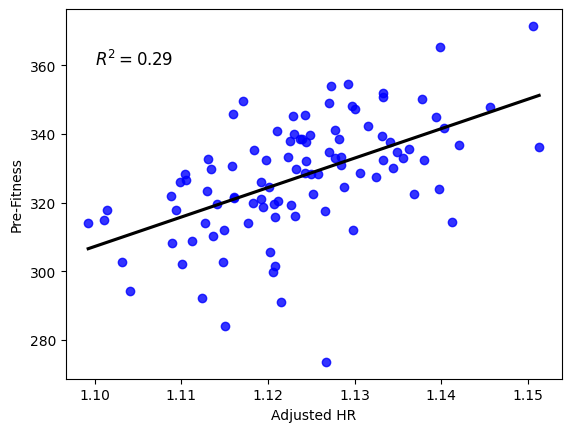

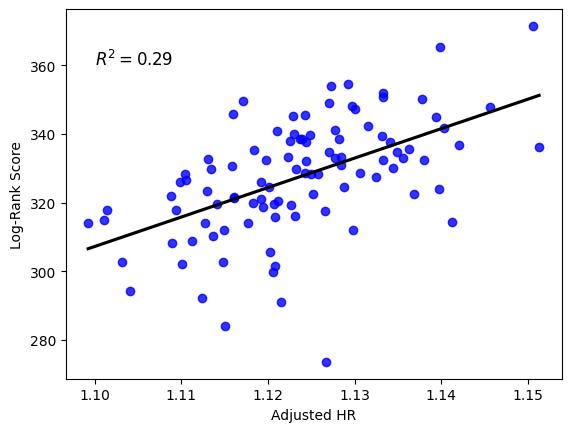

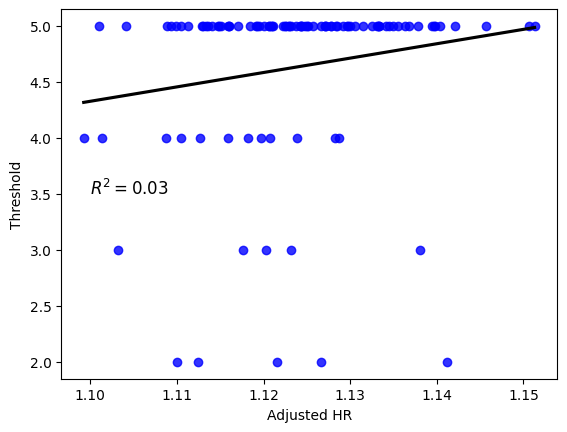

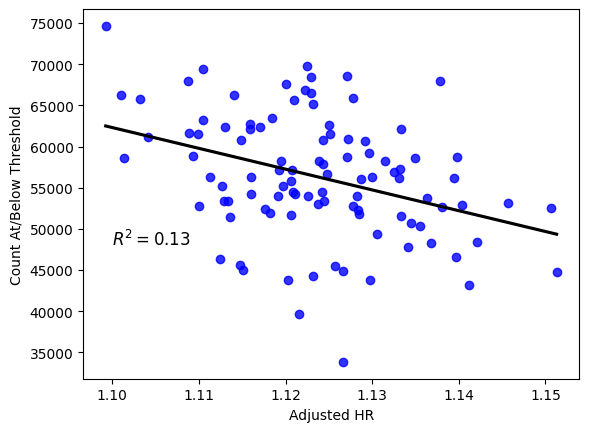

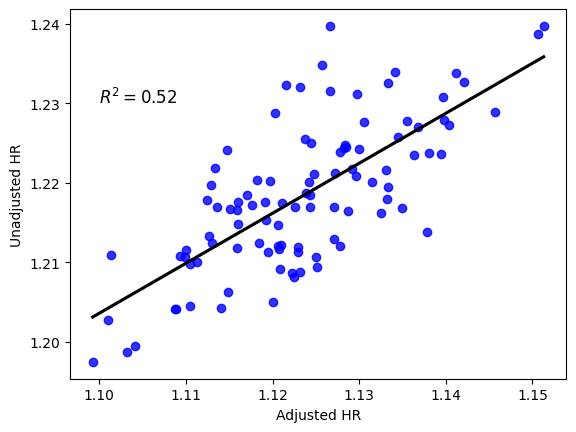

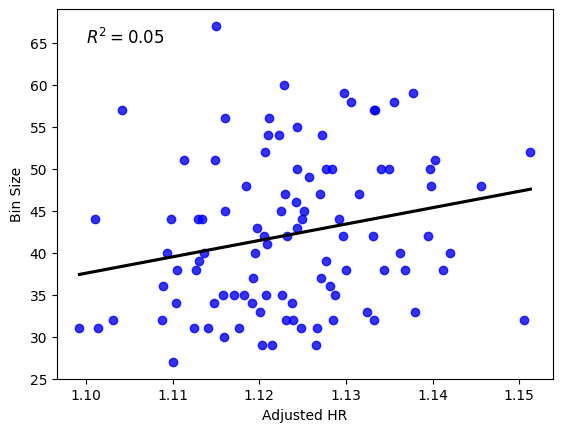

In [11]:
if experiment_name == 'Fibers2.0_hla_7locus_product_DP3':
    image_name = 'AdjHR_Pre-Fitness'
    x = 'Adjusted HR'
    y = 'Pre-Fitness'
    x_pos = 1.091
    y_pos = 2900
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

    image_name = 'AdjHR_Log-Rank'
    x = 'Adjusted HR'
    y = 'Log-Rank Score'
    x_pos = 1.091
    y_pos = 300
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

    image_name = 'AdjHR_Residuals'
    x = 'Adjusted HR'
    y = 'Residual'
    x_pos = 1.091
    y_pos = 9.5
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

    image_name = 'AdjHR_Threshold'
    x = 'Adjusted HR'
    y = 'Threshold'
    x_pos = 1.091
    y_pos = 3.8
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

    image_name = 'AdjHR_GroupRatio'
    x = 'Adjusted HR'
    y = 'Count At/Below Threshold'
    x_pos = 1.091
    y_pos = 48000
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

    image_name = 'AdjHR_UnadjHR'
    x = 'Adjusted HR'
    y = 'Unadjusted HR'
    x_pos = 1.091
    y_pos = 1.20
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

    image_name = 'AdjHR_BinSize'
    x = 'Adjusted HR'
    y = 'Bin Size'
    x_pos = 1.091
    y_pos = 20
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

elif experiment_name == 'Fibers2.0_hla_7locus_logrank_DP3_nofilter':
    image_name = 'AdjHR_Pre-Fitness'
    x = 'Adjusted HR'
    y = 'Pre-Fitness'
    x_pos = 1.1
    y_pos = 360
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

    image_name = 'AdjHR_Log-Rank'
    x = 'Adjusted HR'
    y = 'Log-Rank Score'
    x_pos = 1.1
    y_pos = 360
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

    image_name = 'AdjHR_Threshold'
    x = 'Adjusted HR'
    y = 'Threshold'
    x_pos = 1.1
    y_pos = 3.5
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

    image_name = 'AdjHR_GroupRatio'
    x = 'Adjusted HR'
    y = 'Count At/Below Threshold'
    x_pos = 1.1
    y_pos = 48000
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

    image_name = 'AdjHR_UnadjHR'
    x = 'Adjusted HR'
    y = 'Unadjusted HR'
    x_pos = 1.1
    y_pos = 1.23
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

    image_name = 'AdjHR_BinSize'
    x = 'Adjusted HR'
    y = 'Bin Size'
    x_pos = 1.1
    y_pos = 65
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

elif experiment_name == 'Fibers2.0_hla_7locus_logrank_DP3_NoAg_nofilter':
    image_name = 'AdjHR_Pre-Fitness'
    x = 'Adjusted HR'
    y = 'Pre-Fitness'
    x_pos = 1.125
    y_pos = 360
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

    image_name = 'AdjHR_Log-Rank'
    x = 'Adjusted HR'
    y = 'Log-Rank Score'
    x_pos = 1.125
    y_pos = 360
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

    image_name = 'AdjHR_Threshold'
    x = 'Adjusted HR'
    y = 'Threshold'
    x_pos = 1.125
    y_pos = 3.5
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

    image_name = 'AdjHR_GroupRatio'
    x = 'Adjusted HR'
    y = 'Count At/Below Threshold'
    x_pos = 1.125
    y_pos = 48000
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

    image_name = 'AdjHR_UnadjHR'
    x = 'Adjusted HR'
    y = 'Unadjusted HR'
    x_pos = 1.125
    y_pos = 1.23
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

    image_name = 'AdjHR_BinSize'
    x = 'Adjusted HR'
    y = 'Bin Size'
    x_pos = 1.125
    y_pos = 65
    scatterplot_compare(df_summary,x,y,image_name,x_pos,y_pos,save=True,show=True)

### Identify and Report on Top Bin
* Identify top bin imputation and random seed
* Get the correct FIBERS object including that top bin
* Report information on top bin

In [12]:
target_metric = 'Adjusted HR'
max_hr_index = df_summary[target_metric].idxmax()

# Get the bin with the highest Adj HR and the corresponding dataname and seed.
max_dataname = df_summary.loc[max_hr_index, data_name_col]
max_seed = df_summary.loc[max_hr_index, seed_name_col]
max_hr_value = df_summary.loc[max_hr_index, target_metric]
print(target_metric+": "+str(max_hr_value))
print("Dataname: "+str(max_dataname))
print("Seed: "+str(max_seed))
data_name = max_dataname + '_'+str(max_seed)
print(data_name)

#pickle_file_name = base_name+'_'+str(replicate)
#Unpickle FIBERS Object that includes the best bin
with open(inputFolder+'/'+max_dataname+'/'+max_dataname+'_'+str(max_seed)+'_fibers.pickle', 'rb') as f:
    fibers = pickle.load(f)
bin_index = 0 # lowest index is the bin with the highest fitness (only reports the bin ranked at the top, despite possible fitness ties for top)
fibers.get_bin_report(bin_index)

Adjusted HR: 1.1512942635254788
Dataname: NewImp_8
Seed: 6
NewImp_8_6


,0
Features in Bin:,"[MM_A_102, MM_A_12, MM_A_120, MM_A_125, MM_A_1..."
Threshold:,5
Fitness,1.0
Pre-Fitness:,336.298566
Log-Rank Score:,336.298566
Log-Rank p-value:,0.0
Bin Size:,52
Group Ratio:,0.268403
Count At/Below Threshold:,44805
Count Above Threshold:,122127


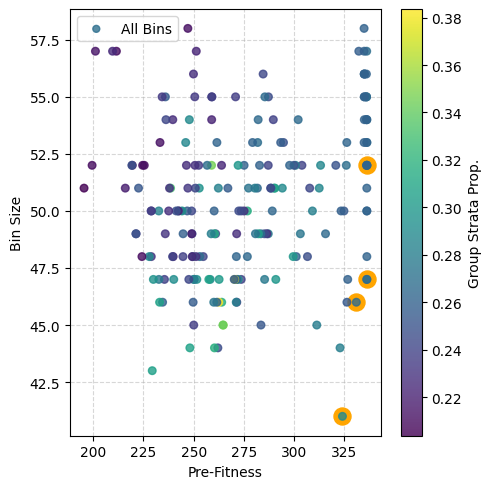

In [13]:
fibers.get_pareto_plot(save=True,output_folder=outputFolder,data_name=data_name)

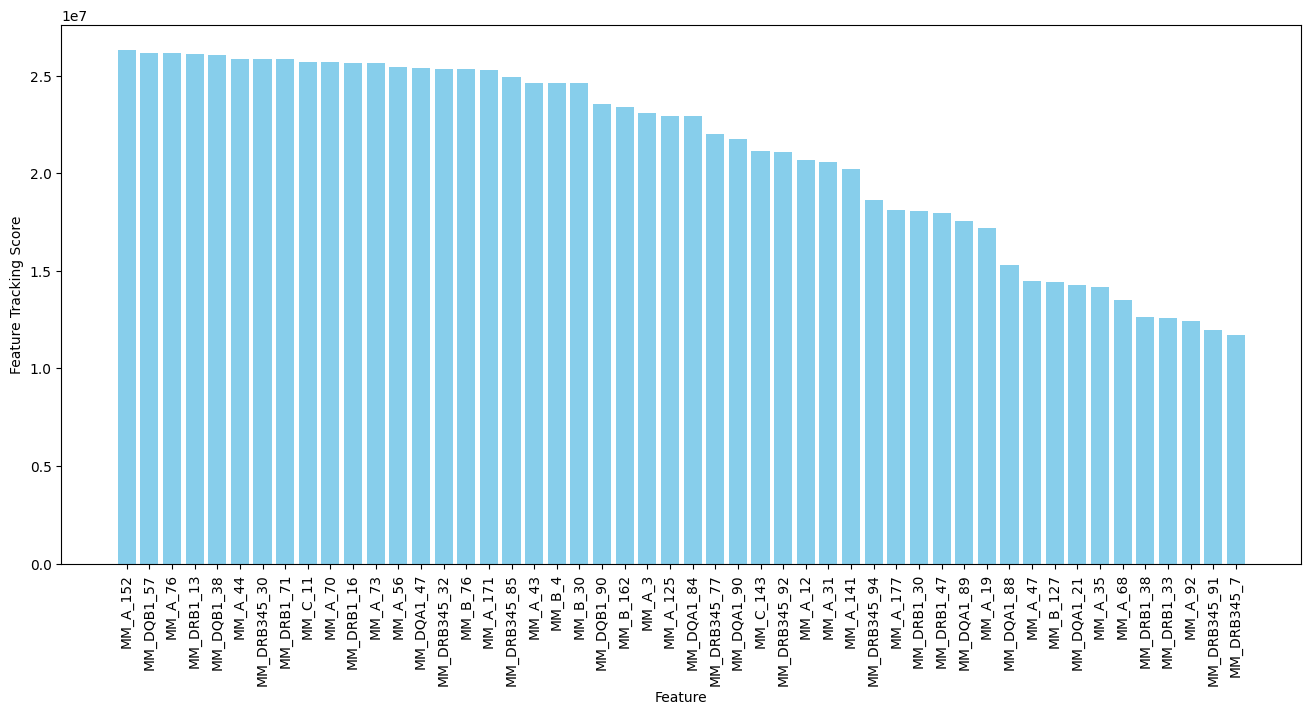

In [14]:
fibers.get_feature_tracking_plot(max_features=50,save=True,output_folder=outputFolder,data_name=data_name)

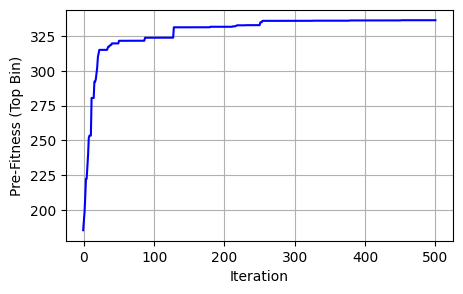

In [15]:
fibers.get_perform_progress_plot(save=True,output_folder=outputFolder,data_name=data_name)

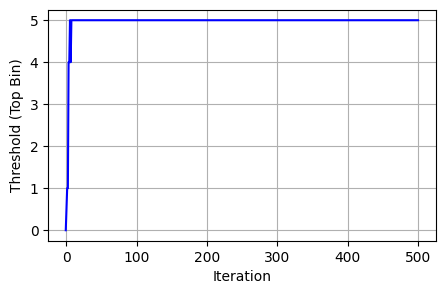

In [16]:
fibers.get_threshold_progress_plot(save=True,output_folder=outputFolder,data_name=data_name)

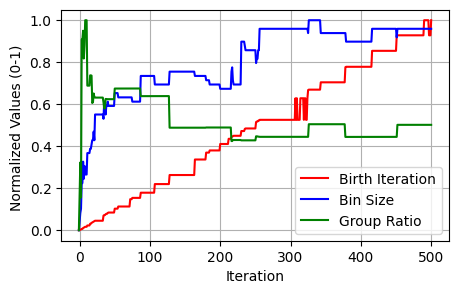

In [17]:
fibers.get_misc_progress_plot(save=True,output_folder=outputFolder,data_name=data_name)